# LeViT-128 Training
Uses `keras_cv_attention_models` (kecam) — a well-established, MIT-licensed community library whose LeViT weights are converted directly from the official Facebook Research LeViT PyTorch checkpoints (verified numerically equivalent by the library maintainer).

Follows the same Phase 1 (frozen) -> Phase 2 (fine-tune) pattern used for the other models (ResNet50, DenseNet121, EfficientNetB0, MobileNetV3, Swin, ViT).

Run cells top to bottom (or Runtime -> Run all).

## Step 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Install keras_cv_attention_models (kecam), which includes LeViT

In [3]:
!pip install -U keras-cv-attention-models -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00


## Step 3 — Verify required files exist in Drive

In [4]:
import os

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

print("split_dataset.zip exists:", os.path.exists(split_zip_path))
print("csv zip exists:", os.path.exists(csv_zip_path))

split_dataset.zip exists: True
csv zip exists: True


## Step 4 — Extract dataset + CSVs

In [5]:
import shutil, zipfile

if not os.path.exists('/content/train'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Dataset ready!")

Dataset ready!


## Step 5 — Load CSVs, fix paths

In [6]:
import pandas as pd

train_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/train_data.csv')
val_df   = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
test_df  = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')

for df in [train_df, val_df, test_df]:
    df['filepath'] = df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(train_df['filepath'].iloc[0]))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

Sample file exists: True
Train/Val/Test: 18037 2519 2538


## Step 6 — Sanity check: confirm pretrained ImageNet weights load correctly
This loads the *original* 1000-class LeViT128 (not yet adapted to our 12 classes) just to confirm the pretrained weights download and load properly, and that predictions are non-trivial (not random noise).

In [7]:
from keras_cv_attention_models import levit
import numpy as np

_test_model = levit.LeViT128(pretrained="imagenet")
_dummy_img = np.random.uniform(0, 255, (1, 224, 224, 3)).astype("float32")
_pred = _test_model(_test_model.preprocess_input(_dummy_img))

print("Output shape:", _pred.shape)  # expected: (1, 1000)
print("Prediction is non-uniform (weights loaded correctly):", np.std(_pred.numpy()) > 0.01)

del _test_model

[WARNING] Setting TF_USE_LEGACY_KERAS=1. Make sure this is ahead of importing tensorflow or keras.
37854624/37854624 [==============================] - 1s 0us/step
>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
Output shape: (1, 1000)
Prediction is non-uniform (weights loaded correctly): True


## Step 7 — tf.data pipeline
LeViT (kecam) expects "torch-style" normalization: pixel/255, then subtract ImageNet mean, divide by ImageNet std. We keep raw float32 [0,255] here and apply that normalization inside the model (Step 9), matching the pattern used in the ViT notebook.

In [8]:
import tensorflow as tf

class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # LeViT128 is lightweight (~9M params); reduce to 16 if you hit OOM

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Classes:", class_names)

Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Step 8 — Sanity-check the backbone's output format
With `num_classes=0`, LeViT should return a pooled feature vector (batch, channels) rather than a spatial map or sequence — confirm this before wiring it into the classification head in Step 9.

In [9]:
_test_backbone = levit.LeViT128(input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet")
_dummy = np.random.uniform(0, 255, (1, 224, 224, 3)).astype(np.float32)
_out = _test_backbone(_dummy)
print("Backbone output shape:", _out.shape)  # expected: (1, channels), e.g. (1, 384)
del _test_backbone

>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
Backbone output shape: (1, 4, 4, 384)


## Step 9 — Build LeViT-128 model (transfer learning)
LeViT128 (~9.2M params) gives a good speed/accuracy balance for the comparison table, and architecturally it sits between the pure-CNN models (ResNet50, DenseNet121, EfficientNetB0, MobileNetV3) and the pure-transformer models (Swin, ViT) — a useful middle point for the thesis discussion.

In [10]:
from tensorflow.keras import layers, models

backbone = levit.LeViT128(input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet")
backbone.trainable = False  # Freeze for Phase 1

inputs = layers.Input(shape=(224, 224, 3), dtype='float32')

# torch-style normalization
mean = tf.constant([0.485, 0.456, 0.406]) * 255.0
std = tf.constant([0.229, 0.224, 0.225]) * 255.0
x = layers.Lambda(lambda t: (t - mean) / std)(inputs)

x = backbone(x)
x = layers.GlobalAveragePooling2D()(x)  # (4D -> 2D): (batch, 4, 4, 384) -> (batch, 384)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 levit128 (Functional)       (None, 4, 4, 384)         8489472   
                                                                 
 global_average_pooling2d_1  (None, 384)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense (Dense)               (None, 256)               98560     
                                                                 
 dropout (Dropout)           (None, 256)               0   

## Step 10 — Callbacks

In [11]:
backup_folder = '/content/drive/MyDrive/thesis_levit_outputs'
os.makedirs(backup_folder, exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f'{backup_folder}/best_levit_model.keras',
    save_best_only=True, monitor='val_accuracy'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)
callbacks = [early_stop, checkpoint, reduce_lr]

## Step 11 — Phase 1 training (train only the new top layers)

In [12]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
564/564 [==============================] - 91s 141ms/step - loss: 0.6939 - accuracy: 0.7950 - val_loss: 0.2321 - val_accuracy: 0.9214 - lr: 0.0010
Epoch 2/10
564/564 [==============================] - 75s 133ms/step - loss: 0.2705 - accuracy: 0.9039 - val_loss: 0.1977 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 3/10
564/564 [==============================] - 73s 129ms/step - loss: 0.2044 - accuracy: 0.9248 - val_loss: 0.1879 - val_accuracy: 0.9313 - lr: 0.0010
Epoch 4/10
564/564 [==============================] - 73s 129ms/step - loss: 0.1616 - accuracy: 0.9399 - val_loss: 0.1685 - val_accuracy: 0.9452 - lr: 0.0010
Epoch 5/10
564/564 [==============================] - 74s 130ms/step - loss: 0.1438 - accuracy: 0.9484 - val_loss: 0.1670 - val_accuracy: 0.9460 - lr: 0.0010
Epoch 6/10
564/564 [==============================] - 71s 125ms/step - loss: 0.1263 - accuracy: 0.9534 - val_loss: 0.1641 - val_accuracy: 0.9444 - lr: 0.0010
Epoch 7/10
564/564 [==============================] 

## Step 12 — Inspect backbone layer count before unfreezing
LeViT's internal structure mixes convolutional patch-embedding with transformer stages, so it isn't a simple linear stack like ResNet or ViT. Check the total layer count here so the slice in Step 13 can be adjusted if needed.

In [13]:
print("Total layers in backbone:", len(backbone.layers))
# Uncomment to inspect layer names/types in detail:
# backbone.summary()

Total layers in backbone: 361


## Step 13 — Phase 2 training (fine-tune the last LeViT blocks)
If this cell errors on the freezing loop, re-check Step 12's layer count and adjust the slice index (`-20` below) accordingly — a good starting point is to unfreeze roughly the last 10-15% of layers.

In [14]:
backbone.trainable = True

# Freeze all but the last ~20 layers (approximates unfreezing the final LeViT stage)
for layer in backbone.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
564/564 [==============================] - 87s 134ms/step - loss: 0.1863 - accuracy: 0.9339 - val_loss: 0.2233 - val_accuracy: 0.9313 - lr: 1.0000e-05
Epoch 2/15
564/564 [==============================] - 73s 129ms/step - loss: 0.1532 - accuracy: 0.9458 - val_loss: 0.2032 - val_accuracy: 0.9365 - lr: 1.0000e-05
Epoch 3/15
564/564 [==============================] - 73s 129ms/step - loss: 0.1356 - accuracy: 0.9525 - val_loss: 0.1966 - val_accuracy: 0.9381 - lr: 1.0000e-05
Epoch 4/15
564/564 [==============================] - 72s 127ms/step - loss: 0.1216 - accuracy: 0.9581 - val_loss: 0.1898 - val_accuracy: 0.9393 - lr: 1.0000e-05
Epoch 5/15
564/564 [==============================] - 75s 132ms/step - loss: 0.1153 - accuracy: 0.9579 - val_loss: 0.1858 - val_accuracy: 0.9416 - lr: 1.0000e-05
Epoch 6/15
564/564 [==============================] - 73s 130ms/step - loss: 0.1014 - accuracy: 0.9653 - val_loss: 0.1857 - val_accuracy: 0.9420 - lr: 1.0000e-05
Epoch 7/15
564/564 [========

## Step 14 — Evaluate on test set

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

with open(f'{backup_folder}/test_results.txt', 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\nTest Accuracy: {test_acc:.4f}\n")

80/80 [==============================] - 12s 148ms/step - loss: 0.1588 - accuracy: 0.9511
Test Loss: 0.1588
Test Accuracy: 0.9511


## Step 15 — Classification report + confusion matrix

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.97      0.97      0.97       197
       Corn_Gray_Leaf_Spot       0.89      0.88      0.89       177
              Corn_Healthy       1.00      0.99      0.99       175
          Corn_Leaf_Blight       0.87      0.89      0.88       173
Rice_Bacterial_Leaf_Blight       0.96      0.95      0.95       294
           Rice_Brown_Spot       0.96      0.93      0.95       271
              Rice_Healthy       0.97      0.98      0.97       331
           Rice_Leaf_Blast       0.90      0.93      0.91       257
          Wheat_Brown_Rust       0.96      0.95      0.95       184
             Wheat_Healthy       0.99      0.99      0.99       207
          Wheat_Loose_Smut       0.96      0.99      0.98        80
         Wheat_Yellow_Rust       0.98      0.97      0.98       192

                  accuracy                           0.95      2538
                 macro avg       0.95      0.9

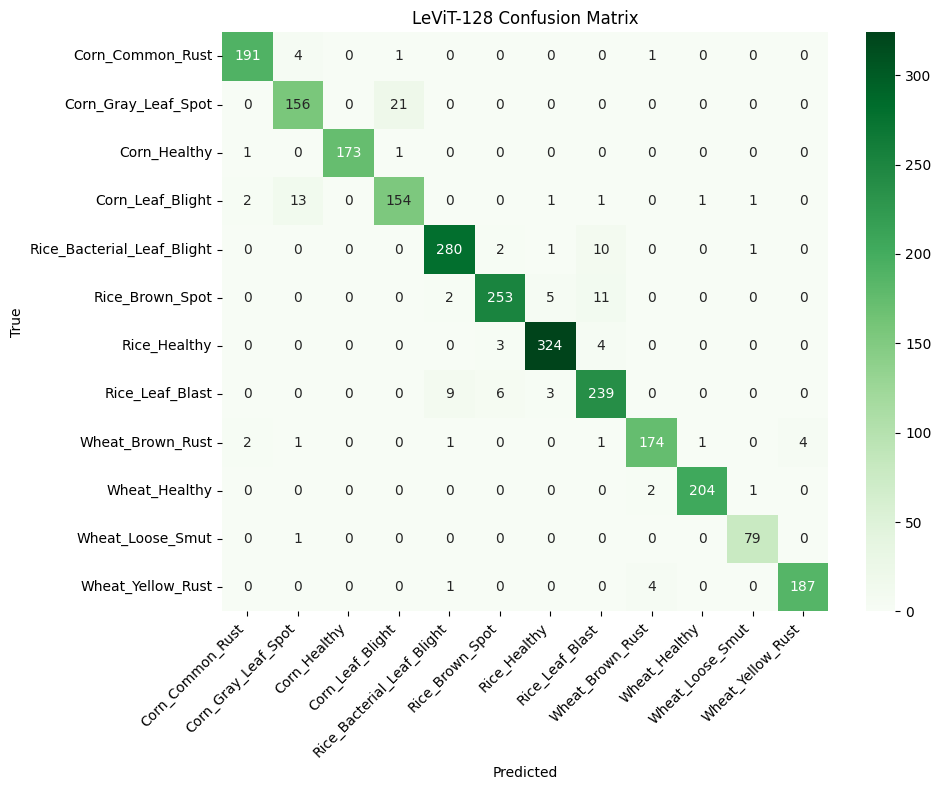

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(f'{backup_folder}/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('LeViT-128 Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{backup_folder}/confusion_matrix.png')
plt.show()

## Step 16 — Model size, parameters, and inference time

In [17]:
import time

tf.get_logger().setLevel('ERROR')

model_path = f'{backup_folder}/best_levit_model.keras'
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)

dummy_input = np.random.uniform(0, 255, (1, 224, 224, 3)).astype(np.float32)
_ = model(dummy_input, training=False)  # warm-up

times = []
for _ in range(100):
    start = time.time()
    _ = model(dummy_input, training=False)
    times.append((time.time() - start) * 1000)

avg_inference_time = np.mean(times)

print("=" * 60)
print("SUMMARY FOR COMPARISON TABLE (LeViT-128)")
print("=" * 60)
print(f"Model size (MB):       {model_size_mb:.2f}")
print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {int(trainable_params):,}")
print(f"Inference time (ms):   {avg_inference_time:.2f}")

SUMMARY FOR COMPARISON TABLE (LeViT-128)
Model size (MB):       34.54
Total parameters:      8,591,116
Trainable parameters:  842,188
Inference time (ms):   260.49


## Step 17 — Single image prediction with confidence

Saving Rice_Bacterial_Leaf_Blight1.jpg to Rice_Bacterial_Leaf_Blight1.jpg
1/1 [==============================] - 0s 114ms/step


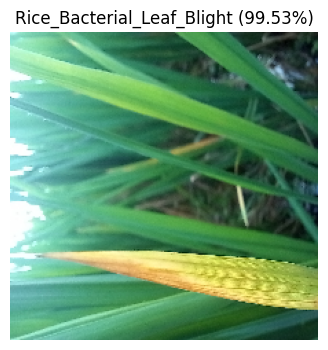

Predicted class: Rice_Bacterial_Leaf_Blight
Confidence: 99.53%

Top 3 predictions:
  Rice_Bacterial_Leaf_Blight: 99.53%
  Rice_Healthy: 0.23%
  Rice_Leaf_Blast: 0.18%


In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img).astype(np.float32)
img_array = np.expand_dims(img_array, axis=0)

preds = model.predict(img_array)
pred_index = np.argmax(preds[0])
pred_class = class_names[pred_index]
confidence = preds[0][pred_index] * 100

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.show()

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

top3_idx = np.argsort(preds[0])[::-1][:3]
print("\nTop 3 predictions:")
for idx in top3_idx:
    print(f"  {class_names[idx]}: {preds[0][idx]*100:.2f}%")